In [11]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [12]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [13]:
from model.metrics import MSE, MAE, evaluate_linear_regression
from model.gradients import MSE_grad, MAE_grad
from model.utils import *
import matplotlib.pyplot as plt

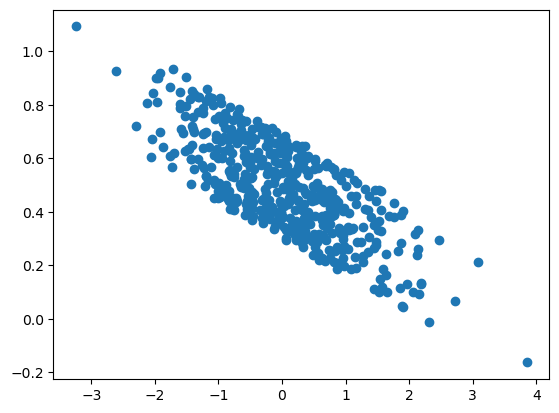

In [14]:
# Sample Code for generating datasets
seed=42
np.random.seed(seed)
size = 500 #資料數
dim = 1 #維度
noise_bound = 0.2 #誤差
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=True) #特徵/預測/ans
plt.scatter(X[:,1],y) # X[:,0]=bias/intercept

In [15]:
# Loading data
loaded_data = np.load(f'data/linear_data/linear_data_D.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1  # 扣掉全是 1 的「截距」column=實際feature數


X size : (8000, 6), y size : (8000,)


50. Training loss: 0.08238685177710688, Val loss:0.08607262493707105
100. Training loss: 0.08238685077138833, Val loss:0.08607247293371127
150. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
200. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
250. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
300. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
350. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
400. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
450. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
500. Training loss: 0.08238685077138833, Val loss:0.08607247293234568


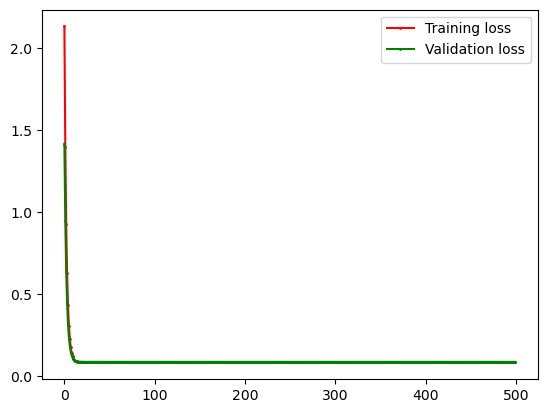

In [16]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function and gradient. 
loss_fn = MSE
grad_fn = MSE_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,True,loss_fn,grad_fn) #dim/is_reg/loss/grad
model.fit(X_train,y_train,lr=0.1,n_iteration =500,val_ratio=0.2)



In [17]:
# Get the Prediction
y_val_pred = model.predict(X_val)

In [18]:
# Evaluation 
# Please complete the evaluate_linear_regression in the model/metrics.py by the sklearn package.
evaluate_linear_regression(y_true=y_val,y_pred=y_val_pred,title='Linear Regression Evaluation')

=== Linear Regression Evaluation ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716


{'MSE': 0.08239246019794483,
 'MAE': 0.24670574882394442,
 'RMSE': np.float64(0.28704086851517296),
 'R-squared': 0.9716056317069087}

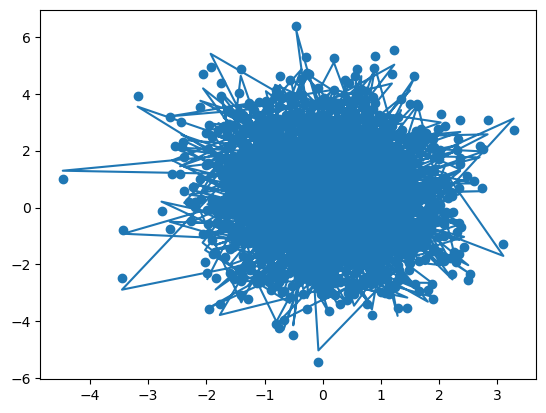

In [19]:
# Plot
plt.scatter(X_val[:,1],y_val)
plt.plot(X_val[:,1],y_val_pred)
plt.show()

50. Training loss: 0.08238685177710688, Val loss:0.08607262493707105
100. Training loss: 0.08238685077138833, Val loss:0.08607247293371127
150. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
200. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
250. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
300. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
350. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
400. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
450. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
500. Training loss: 0.08238685077138833, Val loss:0.08607247293234568


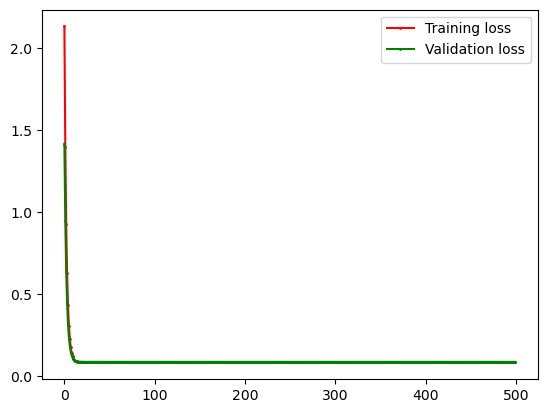

=== Linear Regression Evaluation ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716
50. Training loss: 0.3703643487722049, Val loss:0.368684956398332
100. Training loss: 0.12143459698593069, Val loss:0.12553859557797448
150. Training loss: 0.08770086474185745, Val loss:0.09183236776167002
200. Training loss: 0.08311255449810843, Val loss:0.08699540377230673
250. Training loss: 0.0824862834452406, Val loss:0.08624729244656879
300. Training loss: 0.08240051730594522, Val loss:0.08611372904350847
350. Training loss: 0.08238873475630884, Val loss:0.08608430475529505
400. Training loss: 0.0823871112191, Val loss:0.08607630029028919
450. Training loss: 0.0823868868729943, Val loss:0.08607378489771042
500. Training loss: 0.0823868557883243, Val loss:0.08607293368416796


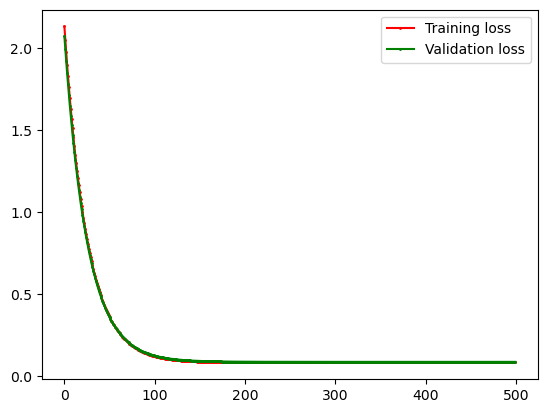

=== Linear Regression Evaluation ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716
50. Training loss: 1.7684511643778449, Val loss:1.7808955296769526
100. Training loss: 1.464852496414385, Val loss:1.4770554865390984
150. Training loss: 1.2159645145907354, Val loss:1.2278106296911493
200. Training loss: 1.0119199428934709, Val loss:1.0233353741451867
250. Training loss: 0.8446325767970521, Val loss:0.8555746535033423
300. Training loss: 0.7074755244845351, Val loss:0.71792454665939
350. Training loss: 0.5950176249327075, Val loss:0.6049705693586137
400. Training loss: 0.50280751484024, Val loss:0.5122732093945561
450. Training loss: 0.4271967232656893, Val loss:0.43619216922708653
500. Training loss: 0.3651947340371162, Val loss:0.37374232354720466


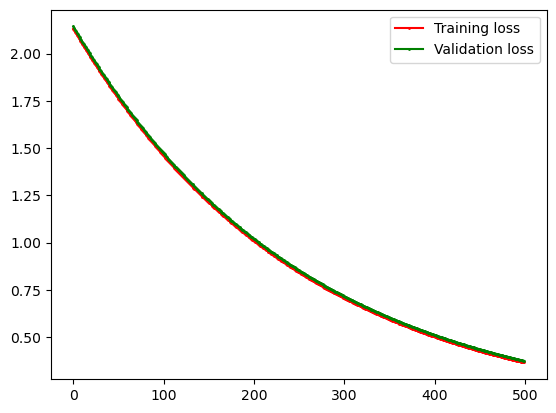

=== Linear Regression Evaluation ===
MSE       : 0.3540
MAE       : 0.4778
RMSE      : 0.5950
R-squared : 0.8780


In [20]:

for lr in [0.1, 0.01, 0.001]:
    np.random.seed(42)
    model0 = LinearModel(dim, True, loss_fn, grad_fn)
    model0.fit(X_train, y_train, lr=lr, n_iteration=500, val_ratio=0.2)
    y_val_pred = model0.predict(X_val)
    evaluate_linear_regression(y_true=y_val,y_pred=y_val_pred,title='Linear Regression Evaluation')